Importing modules

In [4]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import Normalizer, StandardScaler
from collections import Counter
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import tifffile
from utils import get_selectedfeats_sarcasm, predict_classes_train, predict_classes_test
from utils import get_loworg_sarcasm, plot_clusters, plot_pca_matches
from utils import evaluate_from_confusion, get_filenames_fromfolder
from utils import samples_by_label_pair
from utils import plot_gndvspred, pick_random_per_pair

Setting up directories

In [7]:
dataset_parent_dir = '/projectnb/lejlab2/Sara/Second Project/kazuyas-data-project'
csvfiles_parent_dir = ''
figures_parent_dir = ''

# Raw data folder
raw_folder_name = 'dataset'
raw_folder_dir = os.path.join(dataset_parent_dir, raw_folder_name)

# Folder with per-sample sarcasm feature files
sarcasm_features_folder_name = f'{raw_folder_name}_sarcasm_features'
sarcasm_features_dir = os.path.join(dataset_parent_dir, sarcasm_features_folder_name)

# Count available samples based on feature files
print("Total number of data samples is:",
      len(get_filenames_fromfolder(sarcasm_features_dir, file_format="_features.csv")))

# Folder for CSV metadata files
csvfiles_folder_name = 'csv_files'
csvfiles_folder_dir = os.path.join(csvfiles_parent_dir, csvfiles_folder_name)

# Paths to metadata CSV files
traintest_csv_dir = os.path.join(csvfiles_folder_dir, 'metadata_split.csv')
features_csv_dir  = os.path.join(csvfiles_folder_dir, 'metadata_features.csv')  # will be created later

# Folder for figures
figures_folder_name = 'figures'
figures_folder_dir = os.path.join(figures_parent_dir, figures_folder_name)
os.makedirs( figures_folder_dir, exist_ok = True)


Total number of data samples is: 1827


Test and train

In [ ]:
# Load train/test split metadata
df = pd.read_csv(traintest_csv_dir)

# Separate train and test samples
df_train = df[df["split"] == "train"].copy()
df_test  = df[df["split"] == "test"].copy()

# Train set: names + low-org indices
# (low-org indices = samples with n_mbands <= threshold; default thresh=0 but can be changed)
train_names = df_train['name'].to_list()
_, train_idxs_loworg_sarcasm = get_loworg_sarcasm(train_names, sarcasm_features_dir)

# Test set: names + ground-truth labels + low-org indices
test_names  = df_test['name'].to_list()
test_labels = df_test['group_gnd'].to_list()
_, test_idxs_loworg_sarcasm = get_loworg_sarcasm(test_names, sarcasm_features_dir)

# All samples: for global low-org identification
allsamples_names = df['name'].to_list()
_, allsamples_idxs_loworg_sarcasm = get_loworg_sarcasm(allsamples_names, sarcasm_features_dir)


Setting up parameters

In [ ]:
SEED = 1
split_loworg = True        # whether to set aside low-organization samples during clustering
reverse = False            # Relabel clusters by mean PC1: lowest→0 (or highest→0 if reverse=True)

np.random.seed(SEED)

# Selected features used for clustering
include_lst = ['sarcomere_area_ratio', 'z_length_mean', 'n_zbands']


Train

In [ ]:
# Train: selected features
train_features = get_selectedfeats_sarcasm(train_names, sarcasm_features_dir,
                                           raw_folder_dir, include_lst)

# Scale train features
scaler = StandardScaler()
train_features_scaled = scaler.fit_transform(train_features)

# PCA on scaled train features
pca = PCA(n_components=2)
train_features_pca = pca.fit_transform(train_features_scaled)

# Cluster + label train samples
train_pred, kmeans, tree = predict_classes_train(
    train_features_scaled, train_features_pca,
    random_state=SEED, split_loworg=split_loworg,
    idxs_loworg=train_idxs_loworg_sarcasm, reverse=reverse
)

Test

In [ ]:
# test: select, scale, and project test features using train-fitted scaler/PCA 
test_features = get_selectedfeats_sarcasm( test_names, sarcasm_features_dir, raw_folder_dir, include_lst )
test_features_scaled = scaler.transform(test_features)
test_features_pca = pca.transform( test_features_scaled )

test_pred = predict_classes_test( kmeans, tree, test_features_scaled, test_features_pca, random_state = SEED, split_loworg = split_loworg,
                               idxs_loworg = test_idxs_loworg_sarcasm, reverse=reverse )

# all samples
allsamples_names_lst =  allsamples_names 
allsamples_features = get_selectedfeats_sarcasm( allsamples_names, sarcasm_features_dir, raw_folder_dir, include_lst )
allsamples_features_scaled = scaler.transform(allsamples_features)
allsamples_features_pca = pca.transform( allsamples_features_scaled )

_, allsamples_idxs_loworg_sarcasm = get_loworg_sarcasm( allsamples_names, sarcasm_features_dir)
allsamples_pred = predict_classes_test( kmeans, tree, allsamples_features_scaled, allsamples_features_pca, random_state = SEED, split_loworg = split_loworg,
                               idxs_loworg = allsamples_idxs_loworg_sarcasm, reverse=reverse )



class counts : Counter({0.0: 107, 1.0: 67, 2.0: 26})
class counts : Counter({0.0: 1165, 1.0: 492, 2.0: 170})


## Results

Clusters

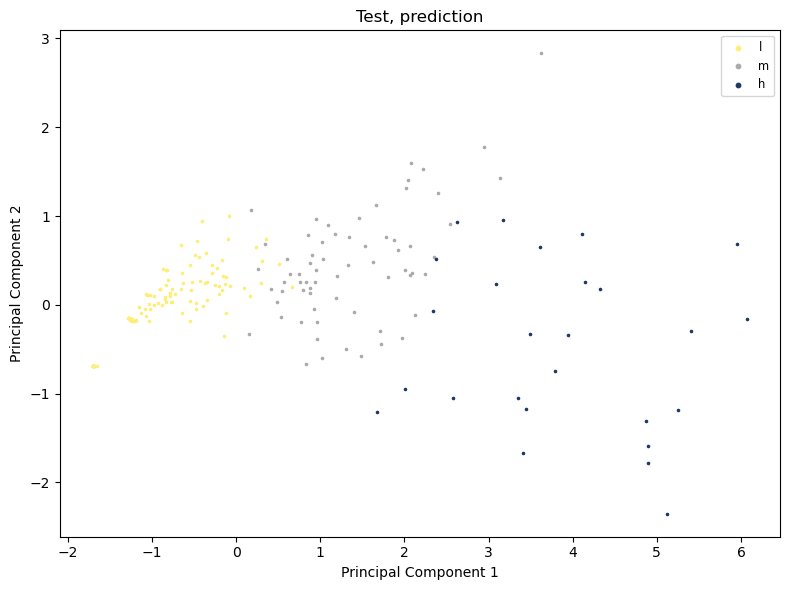

In [ ]:
plot_clusters( test_features_pca,  test_pred, title = 'Test, prediction', saving_dir = f'{figures_folder_dir}/cluster_pred_test.png')

Mistmatches

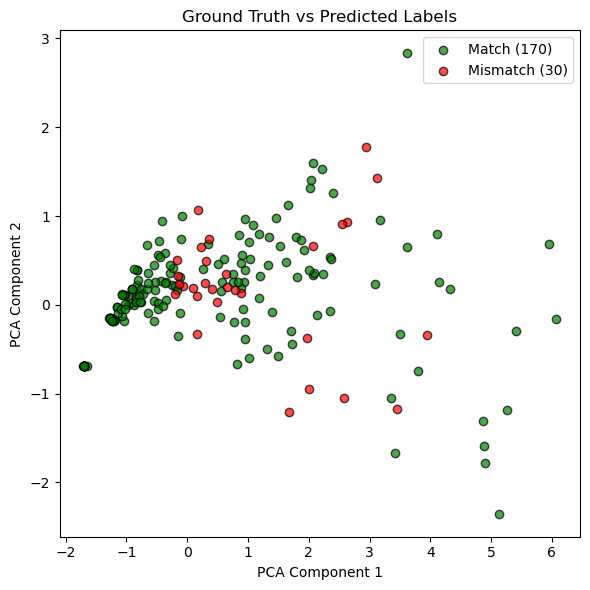

<Axes: title={'center': 'Ground Truth vs Predicted Labels'}, xlabel='PCA Component 1', ylabel='PCA Component 2'>

In [8]:
plot_pca_matches( test_features_pca, np.array( test_labels ), test_pred)

Confusion matrix

In [9]:
cm_test = confusion_matrix(test_labels, test_pred, labels=[0, 1, 2])
_, _, _ = evaluate_from_confusion( cm_test, title = 'test')


For test metrics are:
  Accuracy: 0.850
  Macro precision: 0.826  |  Macro recall: 0.828
  Per-class precision: [0.888 0.821 0.769]
  Per-class recall:    [0.931 0.753 0.800]


<Figure size 640x480 with 0 Axes>

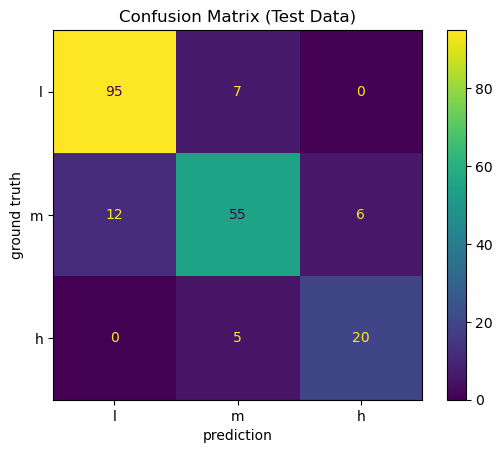

In [10]:

cm_test = confusion_matrix(test_labels, test_pred, labels=[0, 1, 2])
class_names = ['l', 'm', 'h']
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=class_names)
plt.figure()
disp.plot()
disp.ax_.set(xlabel='prediction', ylabel='ground truth')
plt.title("Confusion Matrix (Test Data)")
plt.savefig('figures/cm_test.png', dpi = 400)

Saving the results: metadata_features.csv

# Does this accept nan instead of zero?

In [11]:
# def get_val(col, df_feat):
#     return 0 if pd.isna(df_feat.get(col, pd.Series([np.nan])).iloc[0]) else df_feat[col].iloc[0]

def get_val(col, df_feat):
    return df_feat[col].iloc[0]

df_new = df.copy()
df_new['group_pred'] = allsamples_pred

sarcomere_length_mean_lst, sarcomere_length_std_lst, sarcomere_area_ratio_lst = [], [], []
z_length_mean_lst, n_zbands_lst, cell_mask_area_lst = [], [], []

for name in allsamples_names:
    feat_file = os.path.join(sarcasm_features_dir, f'{name}_features.csv')
    df_feat = pd.read_csv(feat_file)
    sarcomere_length_mean = get_val('sarcomere_length_mean', df_feat)
    sarcomere_length_std = get_val('sarcomere_length_std', df_feat)
    sarcomere_area_ratio = get_val('sarcomere_area_ratio', df_feat)
    z_length_mean = get_val('z_length_mean', df_feat)
    n_zbands = get_val('n_zbands', df_feat)
    cell_mask_area = get_val('cell_mask_area', df_feat)

    sarcomere_length_mean_lst.append( sarcomere_length_mean )
    sarcomere_length_std_lst.append( sarcomere_length_std)
    sarcomere_area_ratio_lst.append( sarcomere_area_ratio)
    z_length_mean_lst.append( z_length_mean)
    n_zbands_lst.append( n_zbands)
    cell_mask_area_lst.append( cell_mask_area)

df_new['sarcomere_length_mean'] = sarcomere_length_mean_lst
df_new['sarcomere_length_std'] = sarcomere_length_std_lst
df_new['sarcomere_area_ratio'] = sarcomere_area_ratio_lst
df_new['z_length_mean'] = z_length_mean_lst
df_new['n_zbands'] = n_zbands_lst
df_new['cell_mask_area'] = cell_mask_area_lst


#-----------------

output_dir = os.path.join(csvfiles_folder_dir, "metadata_features.csv")
df_new.to_csv(output_dir, index=False)


In [12]:
labelpairs_dict = samples_by_label_pair(test_labels, test_pred, test_names, include_empty=True)

In [ ]:
import random

def pick_random_per_pair(labelpairs_dict, seed=0):
    random.seed(seed)

    out = {}
    for key, samples in labelpairs_dict.items():
        if samples:        # non-empty list → pick one
            out[key] = random.choice(samples)
        else:              # empty list → return None
            out[key] = None

    return out

random_samples_dict = pick_random_per_pair(labelpairs_dict, seed = SEED)

No samples for (0.0, 2.0) key
No samples for (2.0, 0.0) key


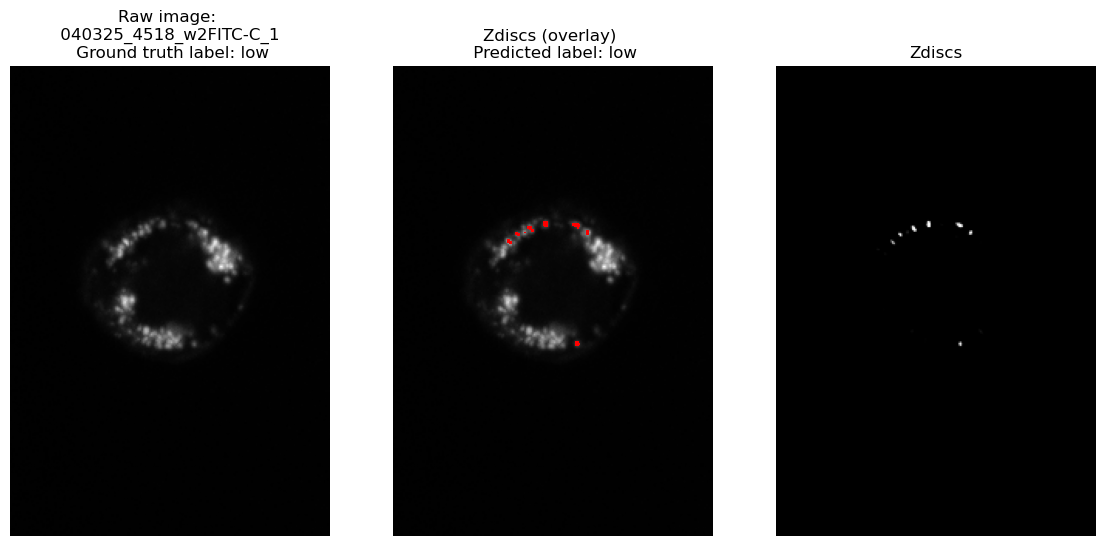

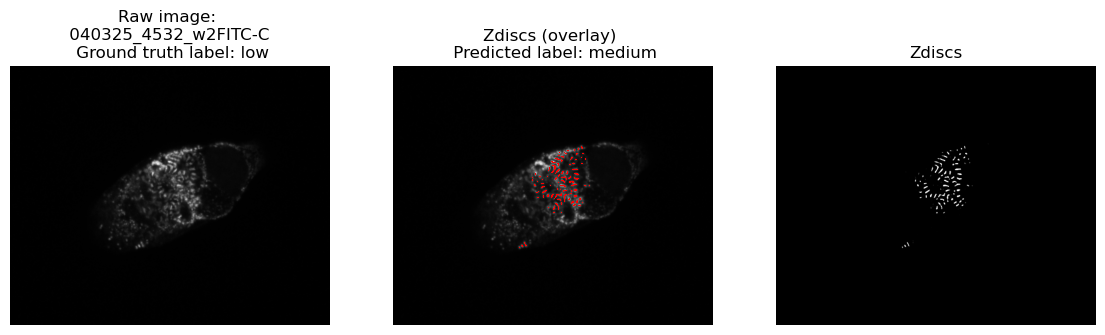

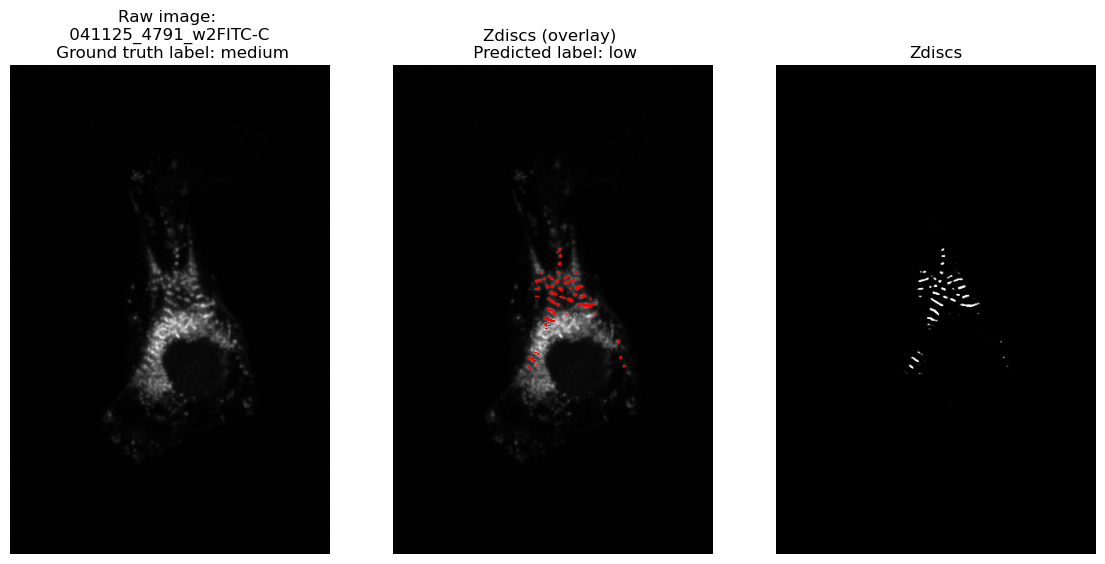

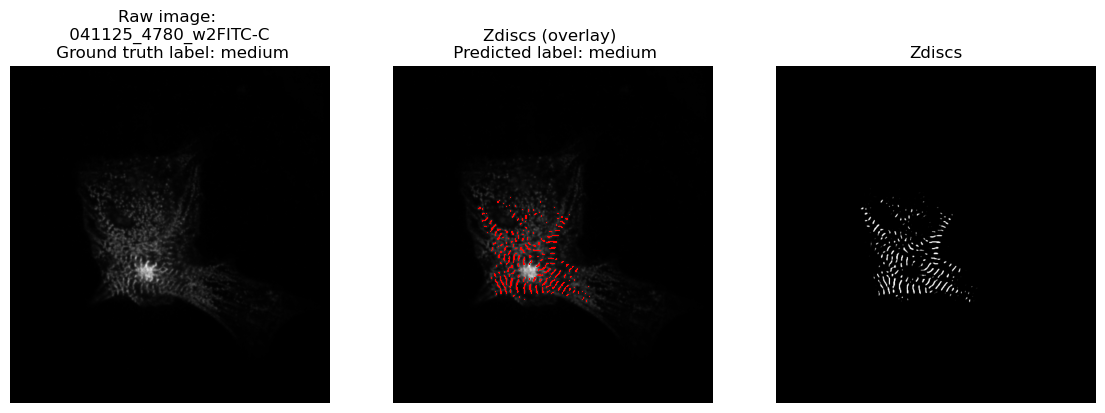

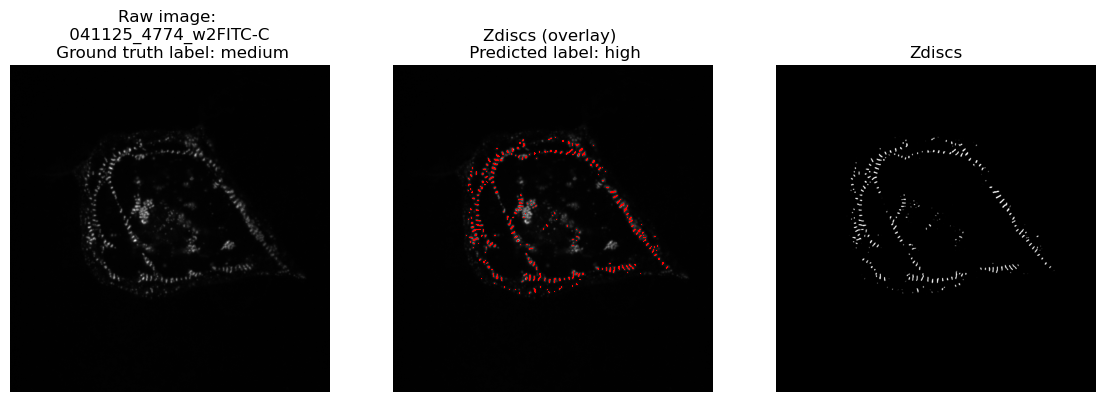

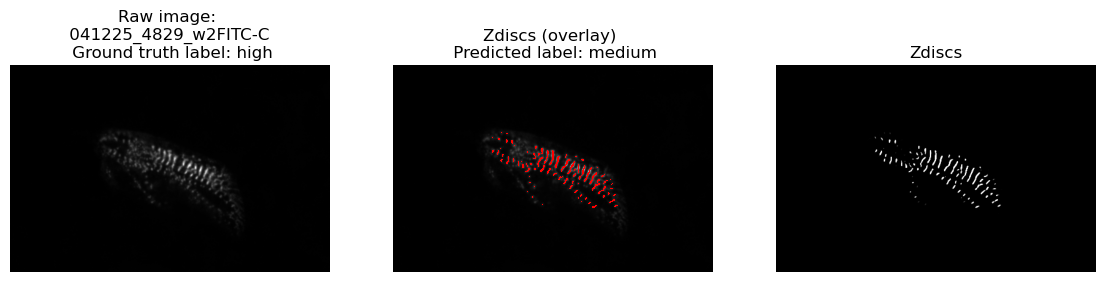

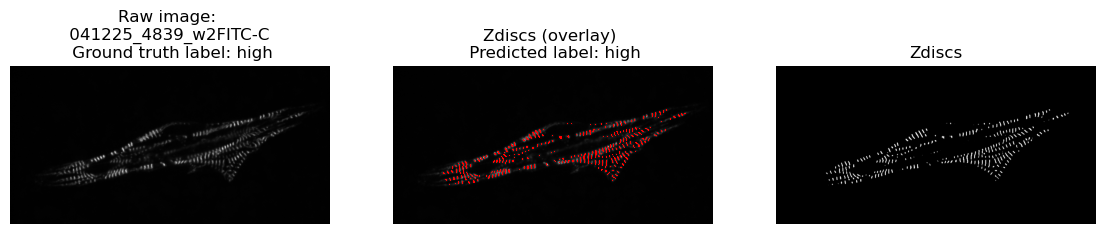

In [14]:
for pair_key, sample_id in random_samples_dict.items():
    if sample_id:
        plot_gndvspred(pair_key, sample_id, raw_folder_dir)
    else:
        print( f'No samples for {pair_key} key')